# 06, Topic Modeling: BERTopic Pipeline vs LLM

Compares two approaches to topic modeling on the sustainable building corpus:

| Approach | Input | Method |
|----------|-------|--------|
| BERTopic pipeline | German text (original) | Unsupervised clustering + c-TF-IDF |
| LLM topic labeling | English translations | Zero-shot classification via Qwen2.5-7B |

**Design**:
- BERTopic runs on the **full corpus** (1,115 articles), unsupervised, no labels needed
- LLM classifies articles into BERTopic-discovered topics using English translations
- Agreement between approaches measured on the 183-article overlap set
- Temporal evolution of topics tracked across 2015-2025

**Evaluation dimensions**:
1. Topic coherence (C_v score)
2. Topic diversity
3. Pipeline vs LLM agreement on the overlap set
4. Temporal stability of topics
5. Trade-off summary


In [32]:
# Install dependencies
!pip install -q bertopic sentence-transformers umap-learn hdbscan gensim
!pip install -q huggingface_hub pandas numpy matplotlib seaborn scipy scikit-learn
!pip install -q 'numpy>=2.0'
print('Done')

Done


In [33]:
import json, pickle, time, re, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 130})
print('Imports OK')

Imports OK


In [34]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
import yaml

PROJECT_ROOT = Path('/content/drive/MyDrive/thesis')
with open(PROJECT_ROOT / 'config.yaml') as f:
    config = yaml.safe_load(f)

SEED        = config.get('seed', 42)
DATA_PROC   = PROJECT_ROOT / 'Project' / 'Data' / 'Processed'
FIGURES_DIR = PROJECT_ROOT / 'Project' / 'Outputs' / 'Figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Config loaded | seed={SEED}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Config loaded | seed=42


In [35]:
# Load corpus
df = pd.read_pickle(DATA_PROC / 'ner_pipeline_results.pkl')
df = df[~df['exclude']].copy()

# LLM checkpoint from notebook 04
with open(DATA_PROC / 'ner_llm_checkpoint.pkl', 'rb') as f:
    llm_ner_results = pickle.load(f)

ok_ids  = {aid for aid, r in llm_ner_results.items() if r['status'] == 'ok'}
df_val  = df[df['article_id'].isin(ok_ids)].copy()

docs_de = df['content'].fillna('').tolist()

print(f'Full corpus  : {len(df)} articles')
print(f'Overlap set  : {len(df_val)} articles (183 with LLM results)')

Full corpus  : 1115 articles
Overlap set  : 183 articles (183 with LLM results)


In [36]:
# Embeddings (cached)
EMBED_CACHE = DATA_PROC / 'topic_embeddings.npy'
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

if EMBED_CACHE.exists():
    embeddings = np.load(EMBED_CACHE)
    print(f'Embeddings loaded from cache: {embeddings.shape}')
else:
    print('Computing embeddings (~5 min)...')
    embeddings = embedding_model.encode(docs_de, show_progress_bar=True, batch_size=32)
    np.save(EMBED_CACHE, embeddings)
    print(f'Embeddings computed and cached: {embeddings.shape}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings loaded from cache: (1115, 384)


In [37]:
# Fit BERTopic (cached)
BERTOPIC_CACHE = DATA_PROC / 'bertopic_model'

umap_model = UMAP(
    n_neighbors=15, n_components=5,
    min_dist=0.0, metric='cosine',
    random_state=SEED
)
hdbscan_model = HDBSCAN(
    min_cluster_size=15, min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

if BERTOPIC_CACHE.exists():
    topic_model = BERTopic.load(str(BERTOPIC_CACHE), embedding_model=embedding_model)
    topics      = topic_model.topics_
    probs       = topic_model.probabilities_
    print('BERTopic model loaded from cache')
else:
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        language='multilingual',
        calculate_probabilities=True,
        verbose=True,
        nr_topics='auto',
    )
    topics, probs = topic_model.fit_transform(docs_de, embeddings)
    topic_model.save(
        str(BERTOPIC_CACHE), serialization='pickle',
        save_ctfidf=True, save_embedding_model=False
    )
    print('BERTopic fitted and saved')

topic_info = topic_model.get_topic_info()
n_topics   = len(topic_info[topic_info['Topic'] != -1])
n_outliers = sum(t == -1 for t in topics)

print(f'Topics found  : {n_topics}')
print(f'Outliers (-1) : {n_outliers} ({n_outliers/len(topics)*100:.1f}%)')
print(topic_info[topic_info['Topic'] != -1][['Topic', 'Count', 'Name']].head(15).to_string())

BERTopic model loaded from cache
Topics found  : 30
Outliers (-1) : 308 (27.6%)
    Topic  Count                                      Name
1       0    160              0_wohnungen_stadt_kfw_wohnen
2       1    110    1_luxemburg_unternehmen_eu_luxemburger
3       2     93      2_holz_architektur_architekten_meter
4       3     55          3_wärmepumpe_energie_wärme_strom
5       4     44            4_regierung_grünen_artikel_csv
6       5     44   5_architekten_bauherrn_bauherr_folglich
7       6     24               6_holz_rauch_designer_schön
8       7     20            7_holz_bambus_wald_unternehmen
9       8     18  8_bauherren_ikea_einfamilienhäuser_eifel
10      9     17     9_wein_karaba_foto chris_chris karaba
11     10     16   10_tiere_landwirtschaft_landwirte_stroh
12     11     16                 11_cfl_trier_bahnhof_gare
13     12     15   12_kinder_universität_campus_birkenfeld
14     13     14               13_kirche_st_inhalt_kirchen
15     14     14       14_beton_rec

In [38]:
# Topic coherence C_v
tokenised  = [doc.lower().split() for doc in docs_de]
dictionary = Dictionary(tokenised)

topic_words = []
for tid in topic_info[topic_info['Topic'] != -1]['Topic']:
    words = [w for w, _ in topic_model.get_topic(tid)[:10]]
    if words:
        topic_words.append(words)

coherence_model = CoherenceModel(
    topics=topic_words, texts=tokenised,
    dictionary=dictionary, coherence='c_v'
)
cv_score  = coherence_model.get_coherence()
all_words = [w for words in topic_words for w in words]
diversity = len(set(all_words)) / len(all_words) if all_words else 0

print(f'C_v coherence  : {cv_score:.4f}  (>0.5 is good)')
print(f'Topic diversity: {diversity:.4f}')
print(f'N topics       : {len(topic_words)}')

C_v coherence  : 0.3971  (>0.5 is good)
Topic diversity: 0.8400
N topics       : 30


In [39]:
# Assign topics to full corpus
df['bertopic_topic'] = topics
df['bertopic_prob']  = [p.max() if hasattr(p, '__len__') else float(p) for p in probs]
topic_name_map       = dict(zip(topic_info['Topic'], topic_info['Name']))
df['bertopic_name']  = df['bertopic_topic'].map(topic_name_map)

print('Topic distribution (top 10):')
print(df[df['bertopic_topic'] != -1]['bertopic_name'].value_counts().head(10).to_string())

Topic distribution (top 10):
bertopic_name
0_wohnungen_stadt_kfw_wohnen                160
1_luxemburg_unternehmen_eu_luxemburger      110
2_holz_architektur_architekten_meter         93
3_wärmepumpe_energie_wärme_strom             55
4_regierung_grünen_artikel_csv               44
5_architekten_bauherrn_bauherr_folglich      44
6_holz_rauch_designer_schön                  24
7_holz_bambus_wald_unternehmen               20
8_bauherren_ikea_einfamilienhäuser_eifel     18
9_wein_karaba_foto chris_chris karaba        17


In [41]:
from sklearn.feature_extraction.text import CountVectorizer
import spacy

nlp = spacy.load('de_core_news_lg')
german_stops = list(nlp.Defaults.stop_words)

vectorizer = CountVectorizer(
    stop_words=german_stops,
    ngram_range=(1, 2),
    min_df=3,        # lowered from 5
    max_df=0.90,     # lowered from 0.95
)

if BERTOPIC_CACHE.exists():
    import os
    os.unlink(str(BERTOPIC_CACHE))

umap_model = UMAP(
    n_neighbors=10, n_components=5,
    min_dist=0.0, metric='cosine',
    random_state=SEED,
)
hdbscan_model = HDBSCAN(
    min_cluster_size=8, min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    language='multilingual',
    calculate_probabilities=True,
    verbose=True,
    nr_topics='auto',
)

embeddings = np.load(EMBED_CACHE)
topics, probs = topic_model.fit_transform(docs_de, embeddings)
topic_model.save(str(BERTOPIC_CACHE), serialization='pickle',
                 save_ctfidf=True, save_embedding_model=False)

topic_info = topic_model.get_topic_info()
n_topics   = len(topic_info[topic_info['Topic'] != -1])
n_outliers = sum(t == -1 for t in topics)

print(f'Topics found  : {n_topics}')
print(f'Outliers (-1) : {n_outliers}')
print(topic_info[topic_info['Topic'] != -1][['Topic', 'Count', 'Name']].head(15).to_string())

2026-04-07 22:23:53,370 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-07 22:24:02,258 - BERTopic - Dimensionality - Completed ✓
2026-04-07 22:24:02,261 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-07 22:24:02,803 - BERTopic - Cluster - Completed ✓
2026-04-07 22:24:02,805 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-07 22:24:07,603 - BERTopic - Representation - Completed ✓
2026-04-07 22:24:07,606 - BERTopic - Topic reduction - Reducing number of topics
2026-04-07 22:24:07,619 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-07 22:24:10,111 - BERTopic - Representation - Completed ✓
2026-04-07 22:24:10,115 - BERTopic - Topic reduction - Reduced number of topics from 42 to 31
2026-04-07 22:24:11,596 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the mod

Topics found  : 30
Outliers (-1) : 308
    Topic  Count                                          Name
1       0    160               0_wohnungen_kfw_wohnen_000 euro
2       1    110                 1_luxemburg_eu_luxemburger_de
3       2     93          2_holz_architektur_architekten_meter
4       3     55              3_wärmepumpe_energie_wärme_strom
5       4     44                4_regierung_grünen_artikel_csv
6       5     44       5_architekten_bauherrn_bauherr_folglich
7       6     24                   6_holz_rauch_designer_schön
8       7     20                        7_holz_bambus_wald_co2
9       8     18  8_bauherren_ikea_einfamilienhäuser_matratzen
10      9     17         9_wein_chris karaba_karaba_foto chris
11     10     16         10_tiere_landwirtschaft_bauern_schafe
12     11     16                 11_karstadt_cfl_trier_bahnhof
13     12     15    12_kinder_universität_campus_umwelt campus
14     13     14                   13_kirche_st_inhalt_kirchen
15     14     14

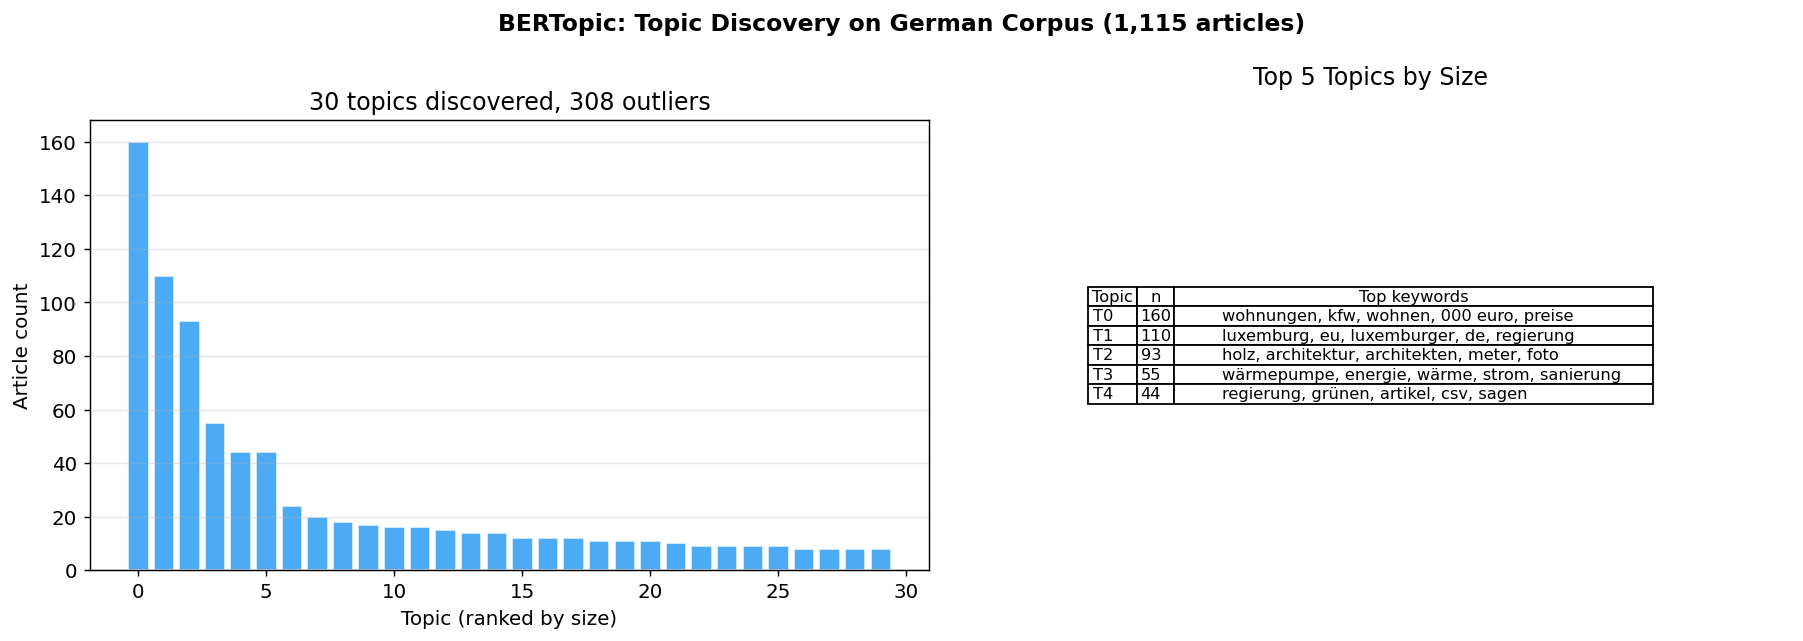

Figure 1 saved


In [42]:
# Figure 1: Topic overview
topic_counts = topic_info[topic_info['Topic'] != -1].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BERTopic: Topic Discovery on German Corpus (1,115 articles)',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.bar(range(len(topic_counts)), topic_counts['Count'].values,
       color='#2196F3', alpha=0.8, edgecolor='white')
ax.set_xlabel('Topic (ranked by size)')
ax.set_ylabel('Article count')
ax.set_title(f'{n_topics} topics discovered, {n_outliers} outliers')
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.axis('off')
top5 = topic_info[topic_info['Topic'] != -1].head(5)
table_data = []
for _, row in top5.iterrows():
    words = ', '.join([w for w, _ in topic_model.get_topic(row['Topic'])[:5]])
    table_data.append([f"T{row['Topic']}", row['Count'], words])
table = ax2.table(cellText=table_data, colLabels=['Topic', 'n', 'Top keywords'],
                  loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width([0, 1, 2])
ax2.set_title('Top 5 Topics by Size', pad=20)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'topic_bertopic_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved')

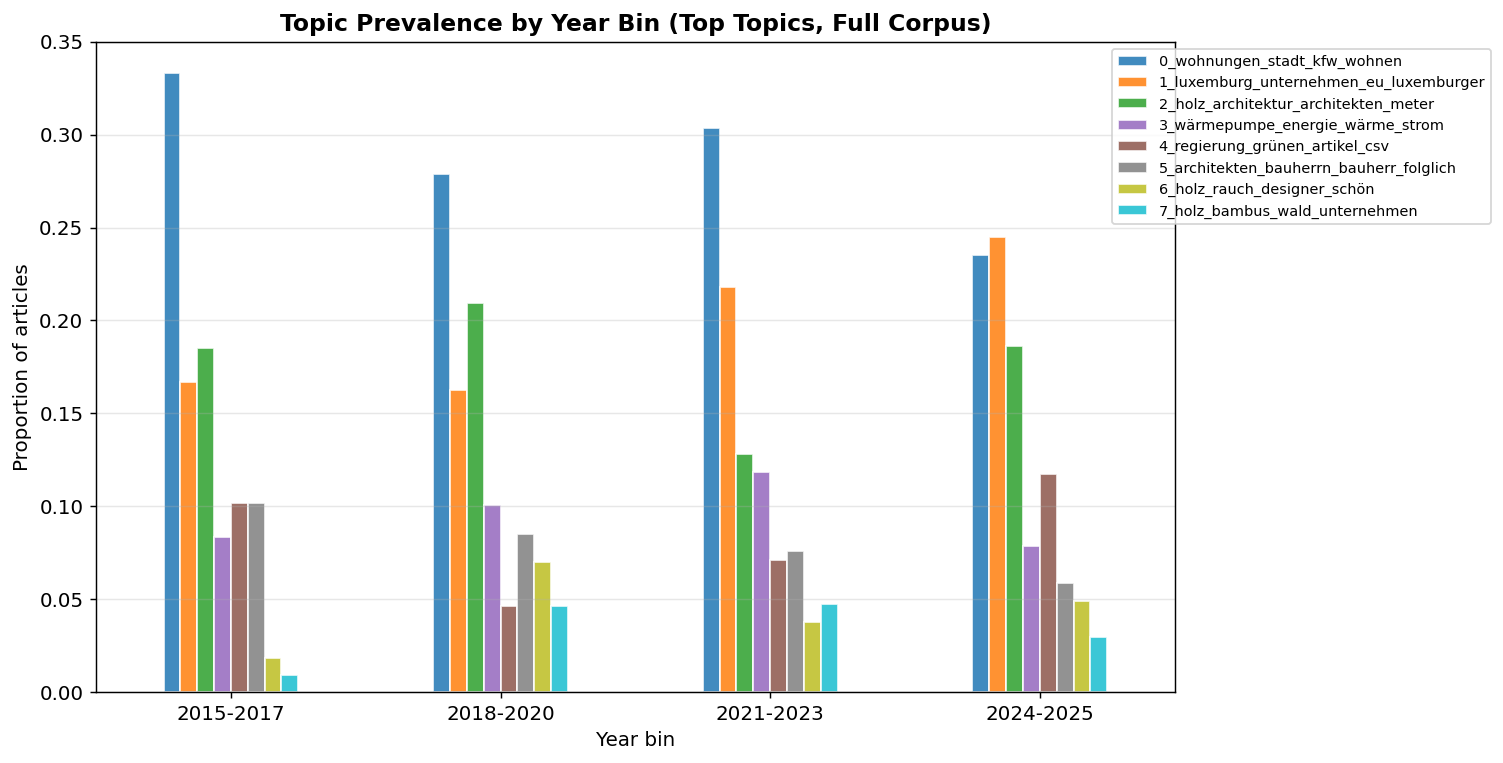

Figure 2 saved
           0_wohnungen_stadt_kfw_wohnen  1_luxemburg_unternehmen_eu_luxemburger  2_holz_architektur_architekten_meter  3_wärmepumpe_energie_wärme_strom  4_regierung_grünen_artikel_csv  5_architekten_bauherrn_bauherr_folglich  6_holz_rauch_designer_schön  7_holz_bambus_wald_unternehmen
year_bin                                                                                                                                                                                                                                                                                     
2015-2017                         0.333                                   0.167                                 0.185                             0.083                           0.102                                    0.102                        0.019                           0.009
2018-2020                         0.279                                   0.163                                 0.209          

In [43]:
# Figure 2: Temporal topic evolution
TOP_N = min(8, n_topics)
top_topic_ids = topic_info[topic_info['Topic'] != -1]['Topic'].head(TOP_N).tolist()

df_topics = df[df['bertopic_topic'].isin(top_topic_ids)].copy()
temporal  = (
    df_topics.groupby(['year_bin', 'bertopic_topic'])
    .size().unstack(fill_value=0)
)
temporal_norm = temporal.div(temporal.sum(axis=1), axis=0)
temporal_norm.columns = [topic_name_map.get(t, f'T{t}') for t in temporal_norm.columns]

fig, ax = plt.subplots(figsize=(12, 6))
temporal_norm.plot(kind='bar', ax=ax, colormap='tab10', alpha=0.85, edgecolor='white')
ax.set_title('Topic Prevalence by Year Bin (Top Topics, Full Corpus)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year bin')
ax.set_ylabel('Proportion of articles')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='upper right', fontsize=8, bbox_to_anchor=(1.3, 1))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'topic_temporal_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved')
print(temporal_norm.round(3).to_string())

In [44]:
print(f'topic_results entries : {len(topic_results)}')
print(f'topic_results ok      : {sum(1 for r in topic_results.values() if r.get("status") == "ok")}')
print(f'df_compare rows       : {len(df_compare)}')
print(f'top_topic_ids         : {top_topic_ids}')

topic_results entries : 0
topic_results ok      : 0
df_compare rows       : 0
top_topic_ids         : [0, 1, 2, 3, 4, 5, 6, 7]


In [45]:
# Save what we have — BERTopic is complete
df[['article_id', 'source', 'year', 'year_bin',
    'bertopic_topic', 'bertopic_name', 'bertopic_prob']].to_csv(
    DATA_PROC / 'topic_bertopic_assignments.csv', index=False
)

summary = {
    'n_articles_full_corpus' : int(len(df)),
    'n_topics_discovered'    : int(n_topics),
    'n_outliers'             : int(n_outliers),
    'outlier_rate'           : round(n_outliers / len(df), 3),
    'cv_coherence'           : round(float(cv_score), 4),
    'topic_diversity'        : round(float(diversity), 4),
    'llm_classification'     : 'not_completed',
    'llm_reason'             : 'API credit exhaustion across all free-tier providers',
    'n_comparison_articles'  : 0,
    'llm_exact_match_rate'   : None,
    'cohens_kappa'           : None,
}

with open(DATA_PROC / 'topic_modeling_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved')
print(json.dumps(summary, indent=2))

Saved
{
  "n_articles_full_corpus": 1115,
  "n_topics_discovered": 30,
  "n_outliers": 308,
  "outlier_rate": 0.276,
  "cv_coherence": 0.3971,
  "topic_diversity": 0.84,
  "llm_classification": "not_completed",
  "llm_reason": "API credit exhaustion across all free-tier providers",
  "n_comparison_articles": 0,
  "llm_exact_match_rate": null,
  "cohens_kappa": null
}
